# Lab 02: Differentiating Degradation: Analytical, Autograd, & Finite Differences

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/02_degradation_autograd.ipynb)


**Learning objective.** Differentiate the normalised quadratic degradation law, compare analytic, automatic and finite-difference derivatives, and connect the calculation to a coupled parameter-to-loss map.

**Predict first.** Predict how the residual parameter $\eta=10^{-7}$ affects $g(1)$ and the behaviour of the degradation law near the broken state.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

[Read this lesson in the book](../../book/labs/02_degradation_autograd.html)

This short exercise checks the exact standard normalised
degradation law in the pinned public PhAST source:

$$
g(d)=(1-\eta)(1-d)^2+\eta, \qquad
g'(d)=-2(1-\eta)(1-d).
$$

We use $d=0$ for intact and $d=1$ for broken, $\eta=10^{-7}$, and
`float64`. We compare analytic, automatic and finite-difference
derivatives of this smooth scalar material law. A coupled fracture
derivative also depends on history updates, constraints and the
solution procedure.


In [1]:
# Google Colab environment setup
try:
    import google.colab
    import subprocess
    from pathlib import Path
    if not Path("autumn-school").is_dir() and not Path("notebooks").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
except ImportError:
    pass

from pathlib import Path
import sys

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents, Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()):
        direct = base / "teaching" / "ukacm_autumn_school_2026"
        if (direct / "notebooks" / "day2_helpers").is_dir():
            return direct
        if (base / "notebooks" / "day2_helpers").is_dir():
            return base
        if (base / "autumn-school" / "notebooks" / "day2_helpers").is_dir():
            return base / "autumn-school"
    raise FileNotFoundError("Could not find teaching/ukacm_autumn_school_2026.")

COURSE_ROOT = locate_course_root()
if str(COURSE_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "notebooks"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display

from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Embed a PNG even when nbclient uses a non-interactive Agg backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

print({"course_layout": "teaching/ukacm_autumn_school_2026 located", "torch": torch.__version__, "device": "cpu", "dtype": str(torch.get_default_dtype())})


{'course_layout': 'teaching/ukacm_autumn_school_2026 located', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64'}


In [2]:
from day2_helpers import import_public_phast
phast_info = import_public_phast()
from phast.physics.material import Material

eta = 1.0e-7
material = Material(E=1.0, nu=0.3, Gc=1.0, l0=0.1, rho=1.0, eta_residual=eta)

def g_analytic(d):
    return (1.0 - eta) * (1.0 - d) ** 2 + eta

def gp_analytic(d):
    return -2.0 * (1.0 - eta) * (1.0 - d)

d = torch.tensor(0.25, dtype=torch.float64, requires_grad=True)
g_phast = material.degradation(d)
(g_ad,) = torch.autograd.grad(g_phast, d)
h = 1.0e-6
g_fd = (g_analytic(d.detach() + h) - g_analytic(d.detach() - h)) / (2.0 * h)
expected = gp_analytic(d.detach())
print({
    "public_source": phast_info,
    "d": float(d.detach()),
    "g_from_public_material": float(g_phast.detach()),
    "analytic_g_prime": float(expected),
    "autograd_g_prime": float(g_ad),
    "central_fd_g_prime": float(g_fd),
})


{'public_source': {'source': 'vendor/PhAST/src (manifest-verified when vendored)', 'module_file': 'phast/__init__.py', 'revision': 'f6324f899f0701769810be117f27f1208f7a582e', 'version': '0.16.2', 'import_route': 'PYTHONPATH=<public-PhAST>/src', 'verification': 'COURSE_SOURCE_MANIFEST.json hashes verified'}, 'd': 0.25, 'g_from_public_material': 0.56250004375, 'analytic_g_prime': -1.49999985, 'autograd_g_prime': -1.49999985, 'central_fd_g_prime': -1.4999998499964917}


In [3]:
endpoints = material.degradation(torch.tensor([0.0, 1.0], dtype=torch.float64))
ad_error = abs(float(g_ad - expected))
fd_error = abs(float(g_fd - expected))
assert abs(float(endpoints[0]) - 1.0) < 1.0e-12
assert abs(float(endpoints[1]) - eta) < 1.0e-12
assert ad_error < 1.0e-12
assert fd_error < 1.0e-8
print({"g(0)": float(endpoints[0]), "g(1)": float(endpoints[1]), "AD_error": ad_error, "FD_error": fd_error})


{'g(0)': 1.0, 'g(1)': 1e-07, 'AD_error': 0.0, 'FD_error': 3.5083047578154947e-12}


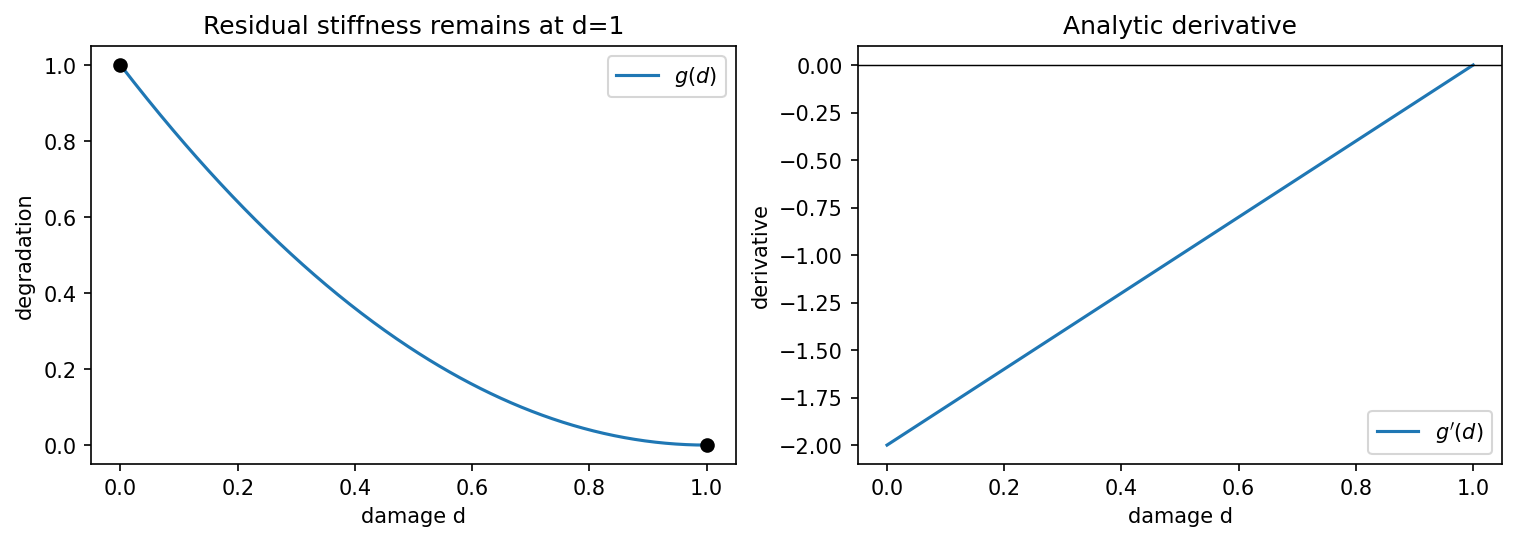

In [4]:
d_plot = torch.linspace(0.0, 1.0, 400, dtype=torch.float64)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(d_plot, material.degradation(d_plot), label=r"$g(d)$")
axes[0].scatter([0, 1], endpoints, color="black", zorder=3)
axes[0].set(xlabel="damage d", ylabel="degradation", title="Residual stiffness remains at d=1")
axes[0].legend()
axes[1].plot(d_plot, gp_analytic(d_plot), label=r"$g'(d)$")
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set(xlabel="damage d", ylabel="derivative", title="Analytic derivative")
axes[1].legend()
fig.savefig(assets_dir() / "degradation_autograd.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Standard degradation function and its analytic derivative over damage from zero to one.")
plt.close(fig)


**Why this matters.** Automatic differentiation follows the tensor
operations connected to a scalar loss. For a complete solver, trace
that connection through the boundary conditions, equilibrium solve,
history update and active constraints. The next exercise develops
this parameter-to-observation chain for an elastic bar.


## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Evaluate the law, its slope, and its curvature

For

$$
g(d)=(1-\eta)(1-d)^2+\eta,
\qquad \eta=10^{-7},
$$

compute $g(0)$, $g(1)$, $g(0.25)$, $g'(0.25)$, and $g''(d)$. State whether $g$ is decreasing and whether it is convex on $0\le d\le1$.

### Exercise 2: Interpret the derivative comparison

At $d=0.25$, the notebook reports analytic and autograd derivatives of $-1.49999985$. Its centred finite difference uses $h=10^{-6}$ and gives $-1.4999998499964917$, with absolute error $3.5083\times10^{-12}$.

1. Write the centred-difference formula used here.
2. Explain what this result checks.
3. Name two additional operations whose derivatives enter a coupled fracture calculation.